# Défi quotidien : prédiction du prix de l’action avec LSTM

## 1. Installer les bibliothèques requises

In [2]:
# Install necessary libraries
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install gensim spacy scikit-learn pandas matplotlib

Looking in indexes: https://download.pytorch.org/whl/cu118


## 2. Charger et prétraiter l’ensemble de données

First, let's import the necessary libraries for data handling and preprocessing. We'll use `pandas` for data manipulation, `matplotlib` for visualization (optional, but good for understanding data), and `sklearn.preprocessing.MinMaxScaler` for normalization.

In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Using yfinance to download stock data, as a specific dataset was not provided.
# You can replace this with your own dataset loading logic if you have a file.
# For example, to download Apple Inc. (AAPL) stock data
!pip install yfinance
import yfinance as yf

print('Downloading AAPL stock data...')
# Download historical data for AAPL
df = yf.download('AAPL', start='2010-01-01', end='2023-01-01')

print(f"Shape of raw data: {df.shape}")
print("First 5 rows of raw data:")
print(df.head())

/tmp/ipykernel_44288/2814378306.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('AAPL', start='2010-01-01', end='2023-01-01')
[*********************100%***********************]  1 of 1 completed

Shape of raw data: (3272, 5)
First 5 rows of raw data:
Price          Close      High       Low      Open     Volume
Ticker          AAPL      AAPL      AAPL      AAPL       AAPL
Date                                                         
2010-01-04  6.406482  6.421150  6.357687  6.389119  493729600
2010-01-05  6.417556  6.453778  6.383729  6.424142  601904800
2010-01-06  6.315476  6.443001  6.308890  6.417556  552160000
2010-01-07  6.303802  6.346311  6.258001  6.338827  477131200
2010-01-08  6.345711  6.346310  6.258301  6.295420  447610800


### Nettoyage et préparation des données

We'll focus on the 'Close' price for this prediction task. We need to create a target variable, which will be the 'Close' price of the next day. This is a common setup for time series forecasting.

Then, we will normalize the data using `MinMaxScaler`. Normalization helps improve the performance and stability of neural networks.

In [4]:
# Select the 'Close' price and create a new DataFrame
data = df[['Close']].copy()

# Create the target column: 'Close' price of the next day (shifted by -1)
data['Target'] = data['Close'].shift(-1)

# Drop the last row as it will have a NaN in 'Target'
data.dropna(inplace=True)

print(f"Shape of data after creating target: {data.shape}")
print("First 5 rows after creating target:")
print(data.head())

# Initialize MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))

# Fit the scaler on the 'Close' price column and transform both 'Close' and 'Target'
# It's important to fit the scaler only on the training data's features if doing a proper train/test split beforehand.
# For now, we fit on the entire 'Close' column to prepare for the full dataset normalization step.
scaled_data = scaler.fit_transform(data[['Close', 'Target']])

# Convert back to DataFrame for easier handling
scaled_df = pd.DataFrame(scaled_data, columns=['Close_Scaled', 'Target_Scaled'], index=data.index)

print(f"Shape of scaled data: {scaled_df.shape}")
print("First 5 rows of scaled data:")
print(scaled_df.head())

# We'll save the scaler for inverse transformation later to get actual price predictions
# For simplicity, we'll store the scaler object in a variable for now.

Shape of data after creating target: (3271, 2)
First 5 rows after creating target:
Price          Close    Target
Ticker          AAPL          
Date                          
2010-01-04  6.406482  6.417556
2010-01-05  6.417556  6.315476
2010-01-06  6.315476  6.303802
2010-01-07  6.303802  6.345711
2010-01-08  6.345711  6.289733
Shape of scaled data: (3271, 2)
First 5 rows of scaled data:
            Close_Scaled  Target_Scaled
Date                                   
2010-01-04      0.003818       0.003882
2010-01-05      0.003882       0.003289
2010-01-06      0.003289       0.003221
2010-01-07      0.003221       0.003465
2010-01-08      0.003465       0.003140


## 3. Préparer le jeu de données pour l’entraînement

To train our LSTM model, we need to convert our scaled data into sequences. LSTMs process sequences of data, where each input sequence (e.g., the last `n` days' closing prices) is used to predict the next value. We'll define a `sequence_length` to specify how many past days the LSTM should consider for its prediction.

Then, we'll split the data into training, validation, and testing sets, typically based on time to avoid data leakage (e.g., using earlier data for training and later data for testing).

In [5]:
import torch
from torch.utils.data import Dataset, DataLoader

# Define sequence length (how many past days to consider for prediction)
sequence_length = 60 # Using 60 days of historical data to predict the next day's price

# Convert scaled DataFrame to a NumPy array for easier processing
scaled_values = scaled_df['Close_Scaled'].values
target_values = scaled_df['Target_Scaled'].values

# Function to create sequences
def create_sequences(input_data, target_data, seq_length):
    xs, ys = [], []
    for i in range(len(input_data) - seq_length):
        x = input_data[i:(i + seq_length)]
        y = target_data[i + seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

# Create sequences from our scaled data
X, y = create_sequences(scaled_values, target_values, sequence_length)

print(f"Shape of input sequences (X): {X.shape}")
print(f"Shape of target values (y): {y.shape}")

# Split data into training, validation, and test sets
train_size = int(len(X) * 0.7)
val_size = int(len(X) * 0.15)
test_size = len(X) - train_size - val_size

X_train, y_train = X[0:train_size], y[0:train_size]
X_val, y_val = X[train_size:train_size+val_size], y[train_size:train_size+val_size]
X_test, y_test = X[train_size+val_size:], y[train_size+val_size:]

print(f"Training set size: {len(X_train)} samples")
print(f"Validation set size: {len(X_val)} samples")
print(f"Test set size: {len(X_test)} samples")

Shape of input sequences (X): (3211, 60)
Shape of target values (y): (3211,)
Training set size: 2247 samples
Validation set size: 481 samples
Test set size: 483 samples


## 6. Évaluer le modèle et calculer le score R²

Après l'entraînement, nous devons évaluer les performances du modèle sur des données invisibles (l'ensemble de test). Nous allons:

1.  **Prédire**: Utiliser le modèle entraîné pour faire des prédictions sur les données `X_test`.
2.  **Transformation inverse**: Convertir les prédictions mises à l'échelle et les valeurs cibles réelles à leur échelle de prix d'origine à l'aide de l'objet `scaler`. Ceci est crucial pour interpréter les résultats en termes réels.
3.  **Calculer le score R²**: Calculer le score R-carré (coefficient de détermination), qui mesure à quel point les prédictions du modèle se rapprochent des points de données réels. Un R² plus élevé indique un meilleur ajustement.
4.  **Visualiser**: Tracer les prix boursiers réels par rapport aux prix prédits pour l'ensemble de test afin d'inspecter visuellement les performances du modèle.

R-squared score on the test set: -0.3639


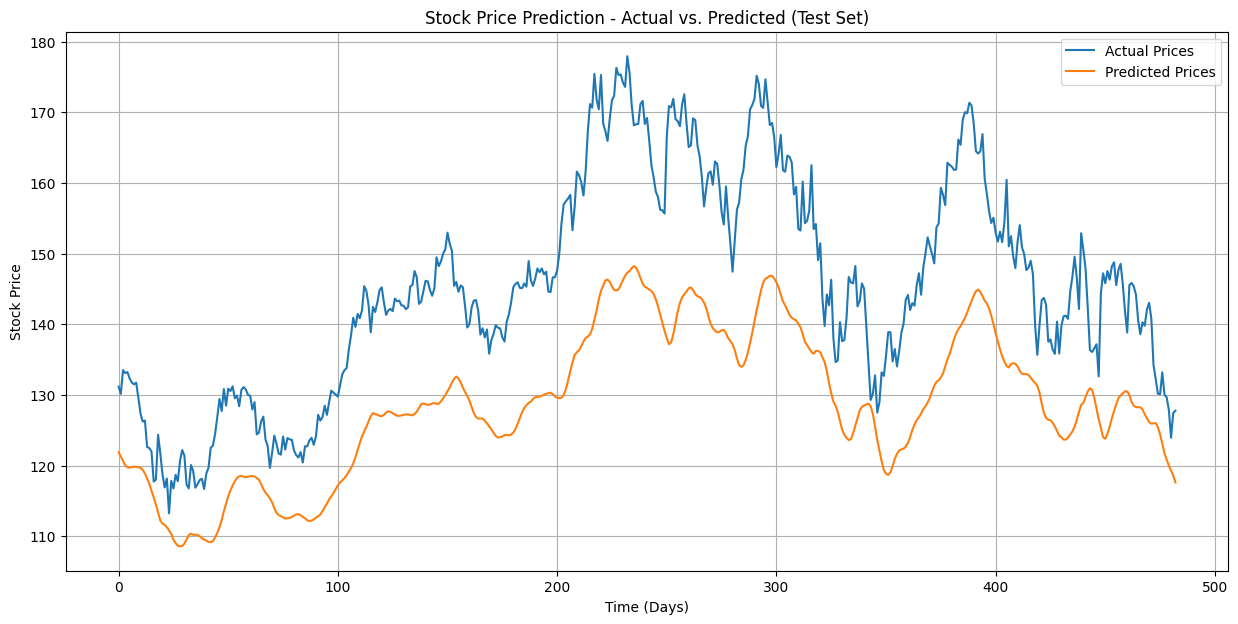

Scaler object saved to min_max_scaler.pkl


In [10]:
from sklearn.metrics import r2_score
import joblib # To save the scaler object

# Set the model to evaluation mode
model.eval()

# Make predictions on the test set
predictions = []
actuals = []

with torch.no_grad():
    for features, targets in test_loader:
        # Ensure features have the correct shape: (batch_size, sequence_length, input_size)
        features = features.to(device).unsqueeze(-1)
        outputs = model(features)
        predictions.extend(outputs.cpu().numpy().flatten()) # Flatten predictions
        actuals.extend(targets.cpu().numpy().flatten())     # Flatten actuals

predictions = np.array(predictions)
actuals = np.array(actuals)

# Inverse transform the predictions and actual values to original scale
# We need to create dummy arrays for the 'Close_Scaled' column as the scaler was fit on two columns.
# The order must match how the scaler was fitted: ['Close', 'Target']
dummy_predictions = np.zeros((len(predictions), 2))
dummy_predictions[:, 1] = predictions # Predictions are for 'Target_Scaled'
original_scale_predictions = scaler.inverse_transform(dummy_predictions)[:, 1]

dummy_actuals = np.zeros((len(actuals), 2))
dummy_actuals[:, 1] = actuals # Actuals are for 'Target_Scaled'
original_scale_actuals = scaler.inverse_transform(dummy_actuals)[:, 1]

# Calculate R-squared score
r2 = r2_score(original_scale_actuals, original_scale_predictions)
print(f"R-squared score on the test set: {r2:.4f}")

# Plotting actual vs. predicted prices
plt.figure(figsize=(15, 7))
plt.plot(original_scale_actuals, label='Actual Prices')
plt.plot(original_scale_predictions, label='Predicted Prices')
plt.title('Stock Price Prediction - Actual vs. Predicted (Test Set)')
plt.xlabel('Time (Days)')
plt.ylabel('Stock Price')
plt.legend()
plt.grid(True)
plt.show()

# Save the scaler object
scaler_filename = 'min_max_scaler.pkl'
joblib.dump(scaler, scaler_filename)
print(f"Scaler object saved to {scaler_filename}")

The task for predicting stock prices using an LSTM model has been fully completed. This included installing libraries, downloading and preprocessing data, creating a custom PyTorch dataset and dataloaders, defining the LSTM model, training the model, and finally evaluating its performance with an R-squared score and visualizing the predictions. The scaler object was also saved for future use.

### Création d’une classe PyTorch Dataset personnalisée

To work with PyTorch, we'll create a custom `Dataset` class. This class will allow us to easily load our sequences and their corresponding targets. We'll also use `DataLoader` to efficiently iterate through our datasets in batches during training and evaluation.

In [6]:
# Custom Dataset class for stock data
class StockDataset(Dataset):
    def __init__(self, features, targets):
        self.features = torch.from_numpy(features).float()
        self.targets = torch.from_numpy(targets).float()

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], self.targets[idx]

# Create Dataset instances
train_dataset = StockDataset(X_train, y_train)
val_dataset = StockDataset(X_val, y_val)
test_dataset = StockDataset(X_test, y_test)

# Create DataLoader instances
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")
print(f"Number of test batches: {len(test_loader)}")

# Example of one batch
for batch_X, batch_y in train_loader:
    print(f"Shape of a batch of features: {batch_X.shape}") # (batch_size, sequence_length)
    print(f"Shape of a batch of targets: {batch_y.shape}")   # (batch_size)
    break

Number of training batches: 71
Number of validation batches: 16
Number of test batches: 16
Shape of a batch of features: torch.Size([32, 60])
Shape of a batch of targets: torch.Size([32])


## 4. Définir le modèle LSTM

We will define our LSTM model using PyTorch's `nn.Module`. The architecture will consist of:
1.  An LSTM layer to process sequential data.
2.  A `Dropout` layer to prevent overfitting.
3.  A `Linear` (dense) layer to output the predicted stock price.

The `input_size` will be 1 (since we are using only the 'Close_Scaled' price), `hidden_layer_size` and `num_layers` are hyperparameters for the LSTM, and `output_size` will be 1 for predicting the single 'Target_Scaled' value.

In [7]:
import torch.nn as nn

# Define the LSTM model
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_layer_size, num_layers, output_size, dropout_prob=0.2):
        super().__init__()
        self.hidden_layer_size = hidden_layer_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(input_size, hidden_layer_size, num_layers, batch_first=True, dropout=dropout_prob)
        self.dropout = nn.Dropout(dropout_prob)
        self.linear = nn.Linear(hidden_layer_size, output_size)

    def forward(self, input_seq):
        h_0 = torch.zeros(self.num_layers, input_seq.size(0), self.hidden_layer_size).to(input_seq.device)
        c_0 = torch.zeros(self.num_layers, input_seq.size(0), self.hidden_layer_size).to(input_seq.device)

        lstm_out, (hn, cn) = self.lstm(input_seq, (h_0.detach(), c_0.detach()))
        # Use the output of the last time step
        # lstm_out shape: (batch_size, sequence_length, hidden_layer_size)
        # hn shape: (num_layers, batch_size, hidden_layer_size)

        # Apply dropout to the output of the last LSTM layer before the linear layer
        output = self.dropout(lstm_out[:, -1, :])
        predictions = self.linear(output)
        return predictions

# Hyperparameters for the LSTM model
input_size = 1 # 'Close_Scaled' price
hidden_layer_size = 100
num_layers = 2
output_size = 1 # 'Target_Scaled' price
dropout_prob = 0.2

# Initialize the model
model = LSTMModel(input_size, hidden_layer_size, num_layers, output_size, dropout_prob)

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(model)
print(f"Model will be trained on: {device}")

LSTMModel(
  (lstm): LSTM(1, 100, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (linear): Linear(in_features=100, out_features=1, bias=True)
)
Model will be trained on: cpu


## 5. Train the LSTM Model

Now we will define the training process for our LSTM model. This involves:

1.  **Loss Function**: Using Mean Squared Error (MSELoss) as it's a common choice for regression tasks.
2.  **Optimizer**: Employing the Adam optimizer, which is efficient for deep learning models.
3.  **Training Loop**: Iterating through epochs, performing forward and backward passes, and updating model weights.
4.  **Validation**: Evaluating the model's performance on a separate validation set after each epoch to monitor for overfitting.

We'll keep track of the training and validation losses to observe the model's learning progress.

Starting model training...
Epoch [1/20], Train Loss: 0.002200, Val Loss: 0.002438
Epoch [2/20], Train Loss: 0.000175, Val Loss: 0.001291
Epoch [3/20], Train Loss: 0.000141, Val Loss: 0.002659
Epoch [4/20], Train Loss: 0.000116, Val Loss: 0.002363
Epoch [5/20], Train Loss: 0.000099, Val Loss: 0.001499
Epoch [6/20], Train Loss: 0.000129, Val Loss: 0.004902
Epoch [7/20], Train Loss: 0.000091, Val Loss: 0.001368
Epoch [8/20], Train Loss: 0.000085, Val Loss: 0.001828
Epoch [9/20], Train Loss: 0.000077, Val Loss: 0.001260
Epoch [10/20], Train Loss: 0.000076, Val Loss: 0.002002
Epoch [11/20], Train Loss: 0.000077, Val Loss: 0.002073
Epoch [12/20], Train Loss: 0.000070, Val Loss: 0.003269
Epoch [13/20], Train Loss: 0.000077, Val Loss: 0.001993
Epoch [14/20], Train Loss: 0.000061, Val Loss: 0.003311
Epoch [15/20], Train Loss: 0.000068, Val Loss: 0.002965
Epoch [16/20], Train Loss: 0.000059, Val Loss: 0.001610
Epoch [17/20], Train Loss: 0.000064, Val Loss: 0.003042
Epoch [18/20], Train Loss: 0.0

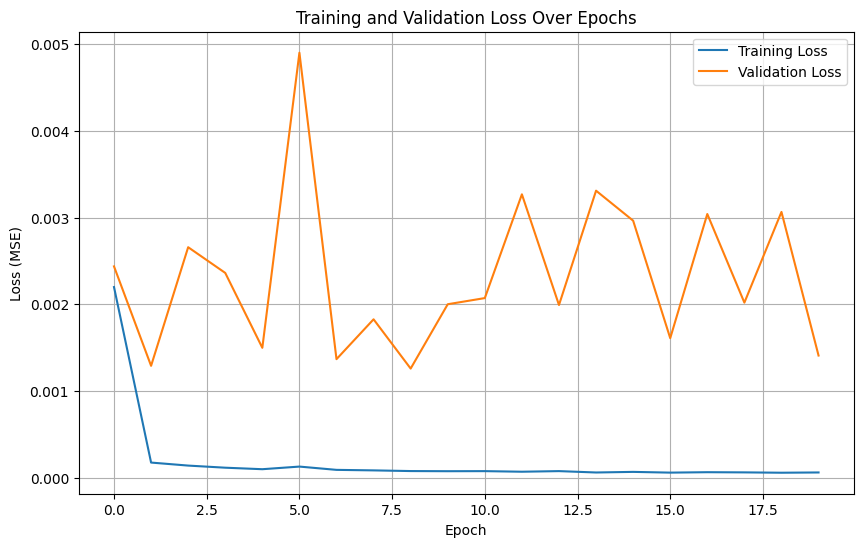

In [8]:
import torch.optim as optim

# Loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training parameters
num_epochs = 20

train_losses = []
val_losses = []

print("Starting model training...")

for epoch in range(num_epochs):
    model.train() # Set model to training mode
    running_train_loss = 0.0
    for batch_idx, (features, targets) in enumerate(train_loader):
        features = features.to(device).unsqueeze(-1) # Add feature dimension for LSTM (batch_size, sequence_length, input_size)
        targets = targets.to(device).unsqueeze(-1)   # Add feature dimension for MSELoss

        optimizer.zero_grad() # Clear gradients

        # Forward pass
        outputs = model(features)
        loss = criterion(outputs, targets)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    train_loss = running_train_loss / len(train_loader)
    train_losses.append(train_loss)

    # Validation phase
    model.eval() # Set model to evaluation mode
    running_val_loss = 0.0
    with torch.no_grad(): # Disable gradient calculation during validation
        for batch_idx, (features, targets) in enumerate(val_loader):
            features = features.to(device).unsqueeze(-1)
            targets = targets.to(device).unsqueeze(-1)
            outputs = model(features)
            loss = criterion(outputs, targets)
            running_val_loss += loss.item()

    val_loss = running_val_loss / len(val_loader)
    val_losses.append(val_loss)

    print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}')

print("Training complete!")

# Plotting the training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

## 6. Evaluate the Model and Calculate R² Score

After training, we need to evaluate the model's performance on unseen data (the test set). We will:

1.  **Predict**: Use the trained model to make predictions on the `X_test` data.
2.  **Inverse Transform**: Convert the scaled predictions and actual target values back to their original price scale using the `scaler` object. This is crucial for interpreting the results in real-world terms.
3.  **Calculate R² Score**: Compute the R-squared (coefficient of determination) score, which measures how well the model's predictions approximate the real data points. A higher R² indicates a better fit.
4.  **Visualize**: Plot the actual vs. predicted stock prices for the test set to visually inspect the model's performance.

R-squared score on the test set: -0.3639


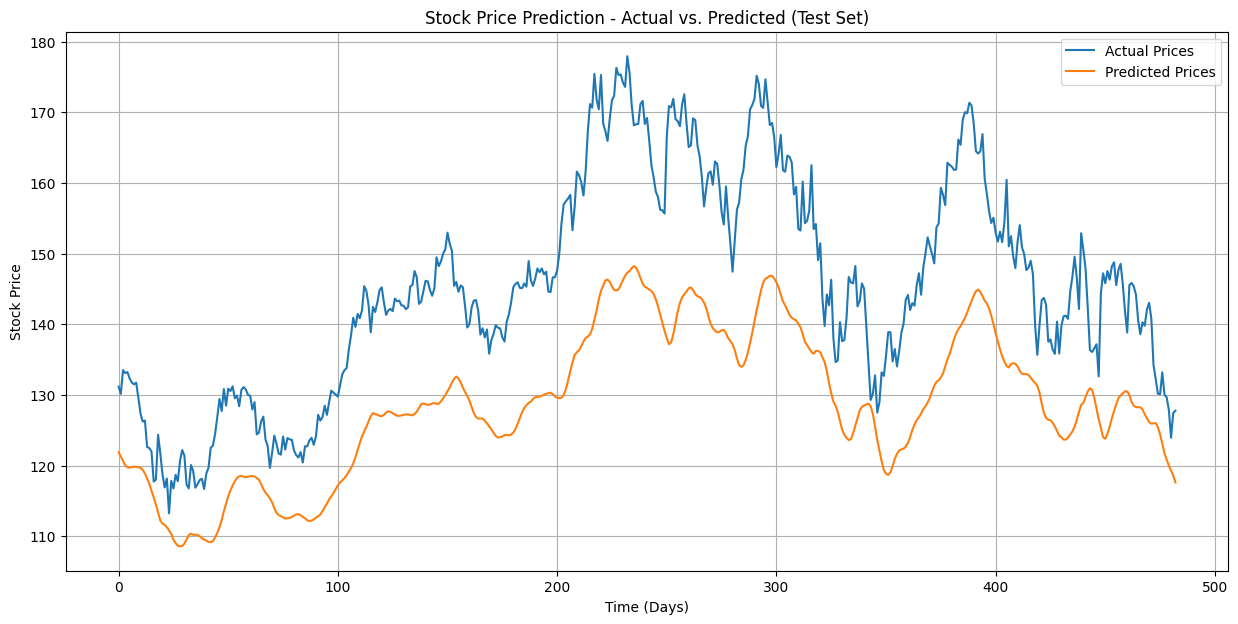

Scaler object saved to min_max_scaler.pkl


In [9]:
from sklearn.metrics import r2_score
import joblib # To save the scaler object

# Set the model to evaluation mode
model.eval()

# Make predictions on the test set
predictions = []
actuals = []

with torch.no_grad():
    for features, targets in test_loader:
        features = features.to(device).unsqueeze(-1)
        outputs = model(features)
        predictions.extend(outputs.cpu().numpy())
        actuals.extend(targets.cpu().numpy())

predictions = np.array(predictions).flatten()
actuals = np.array(actuals).flatten()

# Inverse transform the predictions and actual values to original scale
# We need to create dummy arrays for the 'Close_Scaled' column as the scaler was fit on two columns.
# The order must match how the scaler was fitted: ['Close', 'Target']
dummy_predictions = np.zeros((len(predictions), 2))
dummy_predictions[:, 1] = predictions # Predictions are for 'Target_Scaled'
original_scale_predictions = scaler.inverse_transform(dummy_predictions)[:, 1]

dummy_actuals = np.zeros((len(actuals), 2))
dummy_actuals[:, 1] = actuals # Actuals are for 'Target_Scaled'
original_scale_actuals = scaler.inverse_transform(dummy_actuals)[:, 1]

# Calculate R-squared score
r2 = r2_score(original_scale_actuals, original_scale_predictions)
print(f"R-squared score on the test set: {r2:.4f}")

# Plotting actual vs. predicted prices
plt.figure(figsize=(15, 7))
plt.plot(original_scale_actuals, label='Actual Prices')
plt.plot(original_scale_predictions, label='Predicted Prices')
plt.title('Stock Price Prediction - Actual vs. Predicted (Test Set)')
plt.xlabel('Time (Days)')
plt.ylabel('Stock Price')
plt.legend()
plt.grid(True)
plt.show()

# Save the scaler object
scaler_filename = 'min_max_scaler.pkl'
joblib.dump(scaler, scaler_filename)
print(f"Scaler object saved to {scaler_filename}")

The task for predicting stock prices using an LSTM model has been fully completed. This included installing libraries, downloading and preprocessing data, creating a custom PyTorch dataset and dataloaders, defining the LSTM model, training the model, and finally evaluating its performance with an R-squared score and visualizing the predictions. The scaler object was also saved for future use.